## Imports

In [4]:
import os
import sys
import numpy as np
import time
import scipy
import matplotlib.pyplot as plt
import time
from scipy.stats import binned_statistic
from scipy.interpolate import interp1d

In [141]:
# import the frank2d directory
current_dir =  os.getcwd()
parent_dir = os.path.abspath(os.path.join(current_dir, os.pardir))
sys.path.append(parent_dir)

#frank2d
from frank2d import Frank2D
from constants import rad_to_arcsec, deg_to_rad
import constants
from plot import Plot
from fitting import IterativeSolverMethod
from preprocess_vis import Gridding
from geometry import Geometry

# frank1d
import frank
from frank.geometry import FixedGeometry, SourceGeometry, FitGeometryGaussian
from frank.radial_fitters import FrankFitter
from frank.utilities import UVDataBinner, generic_dht
from frank.hankel import DiscreteHankelTransform

### Functions

In [63]:
def get_vis_profile_deprojected(frank_object, n_bins, range =  None, weighted = False):
    u = frank_object._FT._Un
    v = frank_object._FT._Vn

    inc_r = frank_object._Geometry._inc*constants.deg_to_rad
    pa_r = frank_object._Geometry._pa*constants.deg_to_rad

    cos_i = np.cos(inc_r)
    cos_pa, sin_pa = np.cos(pa_r), np.sin(pa_r)

    u_ = u * cos_pa - v * sin_pa
    v_d = u * sin_pa + v * cos_pa
    u_d = u_ * cos_i
    
    q = np.hypot(u_d, v_d)
    
    Vis = frank_object.sol_visibility
    q = q.flatten()
    Vis = Vis.flatten()
    
    weights_gridded = frank_object._gridded_data['weights']
    Vis_binned, bin_edges, _ = binned_statistic(q, Vis, 'mean', bins = n_bins, range = range)
    q_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    if weighted:
        if range is None:
            Vis_Weights_binned, bin_edges, _ = binned_statistic(q, Vis*weights_gridded, 'sum', bins = n_bins)
            Weights_binned, bin_edges, _ = binned_statistic(q, weights_gridded, 'sum', bins = n_bins)
        else:
            Vis_Weights_binned, bin_edges, _ = binned_statistic(q, Vis*weights_gridded, 'sum', bins = n_bins, range = range)
            Weights_binned, bin_edges, _ = binned_statistic(q, weights_gridded, 'sum', bins = n_bins, range = range)
            
        Vis_Weights_binned = np.nan_to_num(Vis_Weights_binned, nan=0)
        return q_centers, Vis_Weights_binned/Weights_binned

    return q_centers, Vis_binned

### Data

In [10]:
disk_name = 'AS209 1mm'

# Huang 2018 
inc = 34.97
pa = 85.76
dra = 1.9e-3
ddec = -2.5e-3
Rout = 3 #arcsecs

# UVtable
dir = "../../../data/"
data_file = dir +'AS209_continuum_prom_1chan_30s_keepflagsFalse.txt'

 # load data||
u, v, Re, Imag, Weights = np.loadtxt(data_file, unpack = True)
Vis = Re + Imag*1j

In [11]:
geom = SourceGeometry(inc= inc, PA= pa, dRA= dra, dDec= ddec)
u_deproj, v_deproj, vis_deproj = geom.apply_correction(u, v, Vis)

In [192]:
N = 300

In [193]:
m, c, l = -0.33, -0.1, 1e5

### Let's see the gridded visibilities

In [194]:
geom = Geometry(inc, pa, dra, ddec)
frank2d = Frank2D(N, Rout, geom)

In [195]:
frank2d.preprocess_vis(u, v, Vis, Weights, hermitian= False)

  --> time = 0.01  min |  0.43 seconds
Setting gridded data...


/Users/mariajmelladot/Desktop/Frank2D/6_Frank2D_Oficial/frank2d/preprocess_vis.py:46: RuntimeWarning: invalid value encountered in divide
  vis_gridded_matrix =  vis_weights_sum_bin/weights_sum_bin


In [196]:
u_gridded, v_gridded, vis_gridded, weights_gridded = frank2d._gridded_data['u'], frank2d._gridded_data['v'], frank2d._gridded_data['vis'], frank2d._gridded_data['weights']

In [89]:
FT = frank2d._FT
x_labels = np.fft.fftshift(FT._u/1e6)
y_labels = np.fft.fftshift(FT._v/1e6)

num_ticks = 5
x_ticks_to_show = np.linspace(0, len(x_labels) - 1, num_ticks).astype(int)
y_ticks_to_show = np.linspace(0, len(y_labels) - 1, num_ticks).astype(int)

def format_labels(x):
    return f"{int(x):d}" if abs(x) > 1e-8 else "0"

#### Plots

/var/folders/ng/vs__trg57hl3mtgq5kgkzj4h0000gn/T/ipykernel_5428/2364485543.py:1: RuntimeWarning: divide by zero encountered in log
  plt.imshow(np.log(np.abs(np.fft.fftshift(vis_gridded.reshape(frank2d._FT._Nx, frank2d._FT._Ny)))), origin='lower', vmin=-12, vmax=-2)


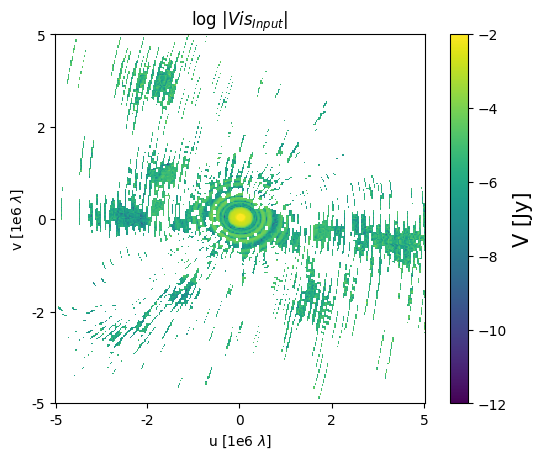

In [90]:
plt.imshow(np.log(np.abs(np.fft.fftshift(vis_gridded.reshape(frank2d._FT._Nx, frank2d._FT._Ny)))), origin='lower', vmin=-12, vmax=-2)
plt.xticks(ticks=x_ticks_to_show, labels=[format_labels(x) for x in np.array(x_labels)[x_ticks_to_show]])
plt.yticks(ticks=y_ticks_to_show, labels=[format_labels(y) for y in np.array(y_labels)[y_ticks_to_show]])
plt.xlabel(r'u [1e6 $\lambda$]')
plt.ylabel(r'v [1e6 $\lambda$]')
plt.title(r'log |$Vis_{Input}$|')
cmap = plt.colorbar()
cmap.set_label(r'V [Jy]', size=15)

In [91]:
u_r = np.fft.fftshift(u_gridded.reshape(frank2d._FT._Nx, frank2d._FT._Ny))
v_r = np.fft.fftshift(v_gridded.reshape(frank2d._FT._Nx, frank2d._FT._Ny))
vis_r = np.fft.fftshift(vis_gridded.reshape(frank2d._FT._Nx, frank2d._FT._Ny))

In [93]:
n = 3.6e6
cond = np.where((u_r > n) | (u_r < -n) | (v_r > n)  | (v_r < -n))
cond

(array([  0,   0,   0, ..., 299, 299, 299]),
 array([  0,   1,   2, ..., 297, 298, 299]))

In [94]:
#vis_r[np.where((np.hypot(u_r, v_r) >=3.6e6))] = 2e6
vis_r[cond] = 0

/var/folders/ng/vs__trg57hl3mtgq5kgkzj4h0000gn/T/ipykernel_5428/2861511446.py:2: RuntimeWarning: divide by zero encountered in log
  plt.pcolormesh(v_r, u_r, np.log(np.abs(vis_r)))


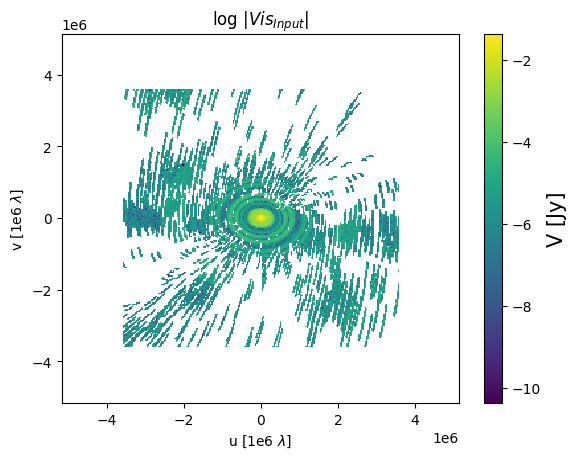

In [209]:
plt.clf()
plt.pcolormesh(v_r, u_r, np.log(np.abs(vis_r)))
plt.xlabel(r'u [1e6 $\lambda$]')
plt.ylabel(r'v [1e6 $\lambda$]')
plt.title(r'log |$Vis_{Input}$|')
cmap = plt.colorbar()
cmap.set_label(r'V [Jy]', size=15)

### Running F2D

In [101]:
vis = np.fft.fftshift(vis_r).flatten()

In [197]:
start_time = time.time()

#####
frank2d = Frank2D(N, Rout, Geometry(inc, pa, dra, ddec))
frank2d.set_kernel('Wendland', [m, c, l])
#frank2d.set_gridded_data(u_gridded, v_gridded, vis, weights_gridded)
frank2d.fit(u, v, Vis, Weights, method = 'bicgstab', rtol = 1e-15)

#####
print("--------------------------------------")
end_time = time.time()
execution_time = end_time - start_time
print(f'time = {execution_time/60 :.2f}  min | {execution_time: .2f} seconds')

Setting kernel: Wendland...
Gridding...
  --> time = 0.05  min |  2.72 seconds
Setting gridded data...
Setting fit with bicgstab ...
Setting guess... Visibilities gridded
Fitting...
  *  Constructing linear operators...
Setting A...
Setting A_precond...
Setting b...
     --> time = 7.25  min |  435.09 seconds
  *  Solving linear system...
     * BICGSTAB
         * rtol: 1e-15
         * final tolerance: 6.0271454498562e-08
         * maxiter:  900000
             .. iteration:  0
             .. iteration:  1
             .. iteration:  2
             .. iteration:  3
             .. iteration:  4
             .. iteration:  5
             .. iteration:  6
             .. iteration:  7
             .. iteration:  8
             .. iteration:  9
             .. iteration:  10
             .. iteration:  11
             .. iteration:  12
             .. iteration:  13
             .. iteration:  14
             .. iteration:  15
             .. iteration:  16
             .. iteration: 

In [198]:
frank2d.fft()

Inverting with 2fft ...
  --> time = 0.00  min |  0.00 seconds


In [210]:
vis_sol = frank2d.sol_visibility.reshape(N, N)

In [211]:
u_, v_ = frank2d._FT._Un, frank2d._FT._Vn

In [212]:
u_, v_ = np.fft.fftshift(u_.reshape(N, N)).flatten(), np.fft.fftshift(v_.reshape(N, N)).flatten()
vis_d = np.fft.fftshift(vis_sol).flatten()

/var/folders/ng/vs__trg57hl3mtgq5kgkzj4h0000gn/T/ipykernel_5428/3665059145.py:1: RuntimeWarning: divide by zero encountered in log
  plt.pcolormesh(v_.reshape(N,N), u_.reshape(N,N), np.log(np.abs(vis_d.reshape(N,N))), cmap="viridis", vmin=-12, vmax=-2)


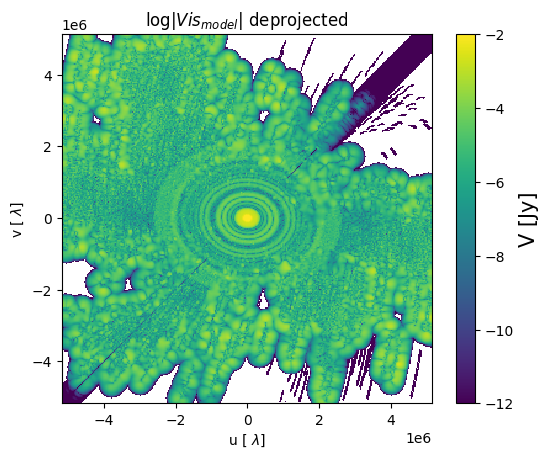

In [213]:
plt.pcolormesh(v_.reshape(N,N), u_.reshape(N,N), np.log(np.abs(vis_d.reshape(N,N))), cmap="viridis", vmin=-12, vmax=-2)
plt.xlabel(r'u [ $\lambda$]')
plt.ylabel(r'v [ $\lambda$]')
plt.gca().set_aspect('equal') 
cmap = plt.colorbar()
cmap.set_label(r'V [Jy]', size=15)
plt.title(r'log|$Vis_{model}$| deprojected')
plt.show()

In [214]:
# Frank 1D Parameters
n_pts = 300
alpha = 1.3
w_smooth = 1e-3

geom = SourceGeometry(inc= inc, PA= pa, dRA= dra, dDec= ddec)
FF = FrankFitter(Rout, n_pts, geom, alpha = alpha, weights_smooth = w_smooth)
sol = FF.fit(u, v, Vis, Weights)

In [215]:
Nbins = N
baselines_edges = np.linspace(sol.q[0], sol.q[-1], Nbins + 1 )
baselines_centers = baselines_edges[:-1] + (baselines_edges[1] - baselines_edges[0])/2
range = (sol.q[0], sol.q[-1])

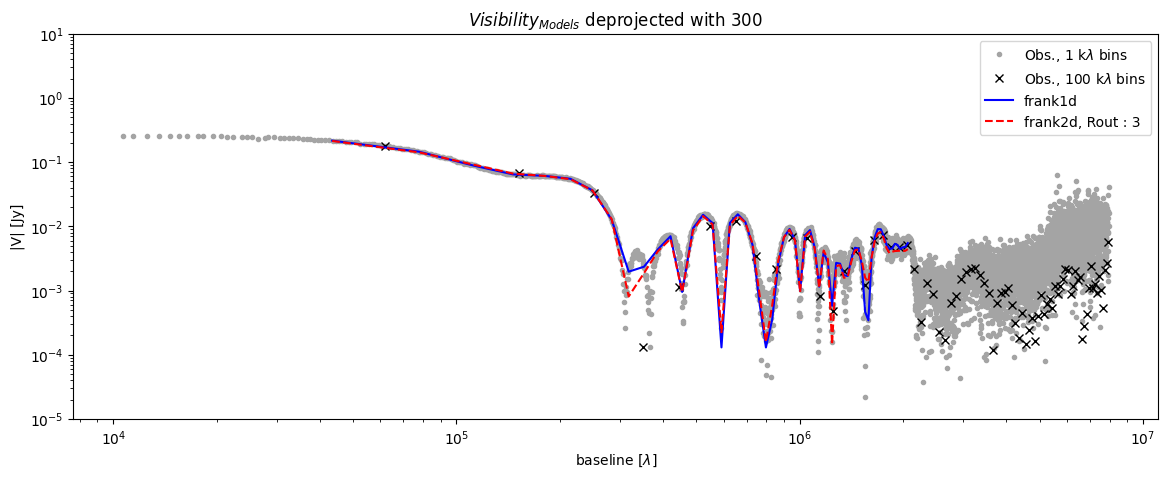

In [216]:
#  Plot variables.
cs, ms = ['#a4a4a4', 'k'], ['.', 'x']
bin_widths = [1e3, 1e5]
baselines = np.hypot(u_deproj, v_deproj)         
grid = np.logspace(np.log10(min(baselines.min(), baselines[0])),
                           np.log10(max(baselines.max(), baselines[-1])),
                           10**4)


plt.figure(figsize=(14,5))
# ---------------------------------------------------------------------------------------------
# Raw visibilities
binned_vis = UVDataBinner(baselines, vis_deproj, Weights, bin_widths[0])
plt.plot(binned_vis.uv, np.abs(binned_vis.V), c=cs[0],
             marker=ms[0], ls='None', 
             label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[0]/1e3))

binned_vis = UVDataBinner(baselines, vis_deproj, Weights, bin_widths[1])
plt.plot(binned_vis.uv, np.abs(binned_vis.V), c=cs[1],
             marker=ms[1], ls='None', 
             label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[1]/1e3))


# --------------------------LOG BINS----------------------------------------------------------
n = 60

#frank1d
vis_fit_1d = sol.predict_deprojected(baselines_centers)
plt.plot(baselines_centers[:n], np.abs(vis_fit_1d)[:n], color = "blue", label = r'frank1d')

# ---------------------------------------------------------------------------------------------

q, Vis_d = get_vis_profile_deprojected(frank2d, baselines_edges, range, weighted = False)
plt.plot(baselines_centers[:n], np.abs(Vis_d)[:n], label = f'frank2d, Rout : '+ str(Rout),ls='--', color = 'red')

# ---------------------------------------------------------------------------------------------


plt.xlabel(r'baseline [$\lambda$]')
plt.xscale('log')
plt.yscale('log')
plt.ylim(1e-5, 10)
#plt.xlim(2e5, 6e6)
plt.ylabel('|V| [Jy]', size = 10)
plt.title(r'$Visibility_{Models}$ deprojected with ' + str(Nbins) )
plt.legend(fontsize= 10, loc = 'best')
plt.show()

In [217]:
Vis_d

array([ 2.14176083e-01+7.68306292e-07j,  1.42571209e-01-3.36824033e-09j,
        9.16385212e-02-2.50982818e-08j,  6.63031566e-02-4.54166323e-09j,
        6.10579220e-02+1.05657813e-07j,  5.43433880e-02-2.44880074e-07j,
        3.63191970e-02+2.95155417e-08j,  1.29604082e-02-1.72879778e-07j,
       -8.07037373e-04-2.63864705e-08j, -1.86380135e-03-5.00547297e-08j,
        4.07586205e-03+3.22080919e-08j,  6.39552558e-03+2.02731379e-06j,
        9.47015052e-04+3.89955069e-06j, -8.63500224e-03-3.88002500e-07j,
       -1.44209742e-02+1.69441776e-06j, -1.07008079e-02+9.79522918e-07j,
       -2.23887504e-04-6.65290534e-06j,  1.03796544e-02-3.42704012e-05j,
        1.46214747e-02-3.76723231e-05j,  1.14809906e-02+7.60673226e-06j,
        5.36146227e-03+4.46902767e-05j,  9.06783650e-04-4.31349758e-05j,
       -1.58022694e-04-1.55690283e-05j, -5.83280638e-04-4.89682102e-06j,
       -2.92933823e-03+4.36669256e-05j, -6.77358227e-03+6.96645788e-05j,
       -8.82304557e-03-2.29237088e-05j, -6.07634687

In [206]:
r, I = generic_dht(baselines_centers, Vis_d, direction = 'backward')

In [207]:
I = I.real
I

array([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, na

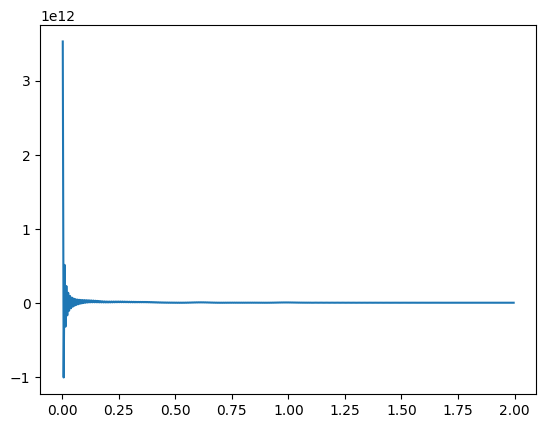

In [191]:
plt.plot(r, I)